# Yield Curve Bootstrapping — neon library

This notebook demonstrates how to construct a **discount curve** from market instruments using sequential bootstrapping.

## What is bootstrapping?

Bootstrapping is a sequential procedure that extracts zero-coupon (spot) rates from the prices of traded instruments — starting from the shortest maturity and working outward. At each step we already know all discount factors up to that point, so the unknown df at the next pillar can be solved analytically.

## Key quantities

| Quantity | Symbol | Definition |
|---|---|---|
| **Discount factor** | df(T) | Present value of $1 paid at time T; df(0)=1, df(T)↘ as T↑ |
| **Zero (spot) rate** | r(T) | Continuously compounded rate: df(T) = exp(−r(T)·T) |
| **Forward rate** | f(T₁,T₂) | Implied rate for the period [T₁, T₂]: df(T₂)/df(T₁) = exp(−f·(T₂−T₁)) |

## Instrument types used

- **Deposit** — a cash deposit from value_date to maturity; df = 1 / (1 + r·t) under simple interest (ACT/360).
- **FRA (Forward Rate Agreement)** — a contract on a future lending rate [start, end]; chains df_end = df_start / (1 + r·t).
- **Par Swap** — a fixed-for-floating rate swap with par fixed rate; df at maturity is solved from the par condition: Σ c·df(tᵢ) + df(T) = 1.

In [1]:
%matplotlib inline
from neon.lib.fixed_income.bootstrapping.deposit import Deposit
from neon.lib.fixed_income.bootstrapping.fra import FRA
from neon.lib.fixed_income.bootstrapping.swap import Swap
from neon.lib.fixed_income.bootstrapping.bootstrapper import CurveBootstrapper
from neon.lib.fixed_income.discount_curve import DiscountCurve
import matplotlib.pyplot as plt
import numpy as np

## 1. Define Market Instruments

We define six market instruments anchoring the curve at:
- **3M and 6M** — short end via deposits (simple interest, ACT/360)
- **1Y, 2Y, 5Y, 10Y** — long end via semi-annual par swaps (ACT/365)

The bootstrapper sorts by maturity automatically, so order here doesn't matter.

In [2]:
VALUE_DATE = "20250101"

instruments = [
    Deposit(VALUE_DATE, "20250401", rate=0.04),    # 3M deposit,  4.00%
    Deposit(VALUE_DATE, "20250701", rate=0.042),   # 6M deposit,  4.20%
    Swap(VALUE_DATE, "20260101", fixed_rate=0.044, coupon_freq=2),  # 1Y swap,  4.40%
    Swap(VALUE_DATE, "20270101", fixed_rate=0.046, coupon_freq=2),  # 2Y swap,  4.60%
    Swap(VALUE_DATE, "20300101", fixed_rate=0.048, coupon_freq=2),  # 5Y swap,  4.80%
    Swap(VALUE_DATE, "20350101", fixed_rate=0.050, coupon_freq=2),  # 10Y swap, 5.00%
]

# Pillar labels for display
pillar_labels = ["3M", "6M", "1Y", "2Y", "5Y", "10Y"]
pillar_dates  = ["20250401", "20250701", "20260101", "20270101", "20300101", "20350101"]

print(f"Value date: {VALUE_DATE}")
print(f"Pillars: {', '.join(pillar_labels)}")

Value date: 20250101
Pillars: 3M, 6M, 1Y, 2Y, 5Y, 10Y


## 2. Bootstrap the Discount Curve

`CurveBootstrapper` sorts instruments by maturity and solves for each discount factor in turn, building a `DiscountCurve` that uses log-linear interpolation in zero rates.

In [3]:
bootstrapper = CurveBootstrapper(VALUE_DATE, instruments)
curve = bootstrapper.build()

print("Bootstrapped curve pillars:")
print(f"{'Pillar':<8}  {'Date':<12}  {'df':>10}  {'Zero Rate':>12}")
print("-" * 48)
for label, date in zip(pillar_labels, pillar_dates):
    df_val  = curve.df(date)
    zr_val  = curve.zero_rate(date)
    print(f"{label:<8}  {date:<12}  {df_val:>10.6f}  {zr_val:>11.4%}")

Bootstrapped curve pillars:
Pillar    Date                  df     Zero Rate
------------------------------------------------
3M        20250401        0.990099      4.0354%
6M        20250701        0.979320      4.2140%
1Y        20260101        0.957392      4.3542%
2Y        20270101        0.912449      4.5811%
5Y        20300101        0.780947      4.9422%
10Y       20350101        0.589817      5.2765%


## 3. Discount Factors at Pillar Dates

Discount factors start at 1.0 today and decay monotonically. The steepness of the decay reflects the level and shape of rates.

In [4]:
print("Discount factor decomposition at each pillar:")
print(f"{'Pillar':<8}  {'Date':<12}  {'df':>10}  {'Δdf from prev':>16}")
print("-" * 52)
prev_df = 1.0
for label, date in zip(pillar_labels, pillar_dates):
    df_val = curve.df(date)
    delta  = df_val - prev_df
    print(f"{label:<8}  {date:<12}  {df_val:>10.6f}  {delta:>+16.6f}")
    prev_df = df_val

Discount factor decomposition at each pillar:
Pillar    Date                  df     Δdf from prev
----------------------------------------------------
3M        20250401        0.990099         -0.009901
6M        20250701        0.979320         -0.010779
1Y        20260101        0.957392         -0.021928
2Y        20270101        0.912449         -0.044943
5Y        20300101        0.780947         -0.131502
10Y       20350101        0.589817         -0.191130


## 4. Zero Rates at Pillar Dates

Continuously compounded zero rates derived from the bootstrapped discount factors. A positive slope indicates a normal (upward-sloping) yield curve.

In [5]:
print("Zero (spot) rates at pillar dates:")
print(f"{'Pillar':<8}  {'Date':<12}  {'Zero Rate (cc)':>16}  {'Par Rate (input)':>18}")
print("-" * 60)

# par rates we input (deposits use simple rate, swaps use par fixed rate)
par_rates = [0.04, 0.042, 0.044, 0.046, 0.048, 0.050]

for label, date, par in zip(pillar_labels, pillar_dates, par_rates):
    zr = curve.zero_rate(date)
    print(f"{label:<8}  {date:<12}  {zr:>16.4%}  {par:>18.4%}")

Zero (spot) rates at pillar dates:
Pillar    Date            Zero Rate (cc)    Par Rate (input)
------------------------------------------------------------
3M        20250401               4.0354%             4.0000%
6M        20250701               4.2140%             4.2000%
1Y        20260101               4.3542%             4.4000%
2Y        20270101               4.5811%             4.6000%
5Y        20300101               4.9422%             4.8000%
10Y       20350101               5.2765%             5.0000%


## 5. Forward Rates Between Pillars

Implied forward rates show the market's expectation of rates in future periods. We compute:
- **3M6M** — rate from 3M to 6M (3 months, starting in 3 months)
- **6M1Y** — rate from 6M to 1Y
- **1Y2Y** — 1-year rate, 1 year forward
- **2Y5Y** — 3-year rate, 2 years forward
- **5Y10Y** — 5-year rate, 5 years forward

In [6]:
forward_pairs = [
    ("3M6M",  "20250401", "20250701"),
    ("6M1Y",  "20250701", "20260101"),
    ("1Y2Y",  "20260101", "20270101"),
    ("2Y5Y",  "20270101", "20300101"),
    ("5Y10Y", "20300101", "20350101"),
]

print("Implied forward rates:")
print(f"{'Period':<8}  {'Start':<12}  {'End':<12}  {'Forward Rate (cc)':>18}")
print("-" * 56)
for label, d1, d2 in forward_pairs:
    fwd = curve.forward_rate(d1, d2)
    print(f"{label:<8}  {d1:<12}  {d2:<12}  {fwd:>18.4%}")

Implied forward rates:
Period    Start         End            Forward Rate (cc)
--------------------------------------------------------
3M6M      20250401      20250701                 4.3906%
6M1Y      20250701      20260101                 4.4921%
1Y2Y      20260101      20270101                 4.8081%
2Y5Y      20270101      20300101                 5.1828%
5Y10Y     20300101      20350101                 5.6108%


## 6. Plot: Zero Rate Curve

The zero rate curve shows the term structure of continuously compounded spot rates. The curve interpolates smoothly between bootstrapped pillars using log-linear interpolation.

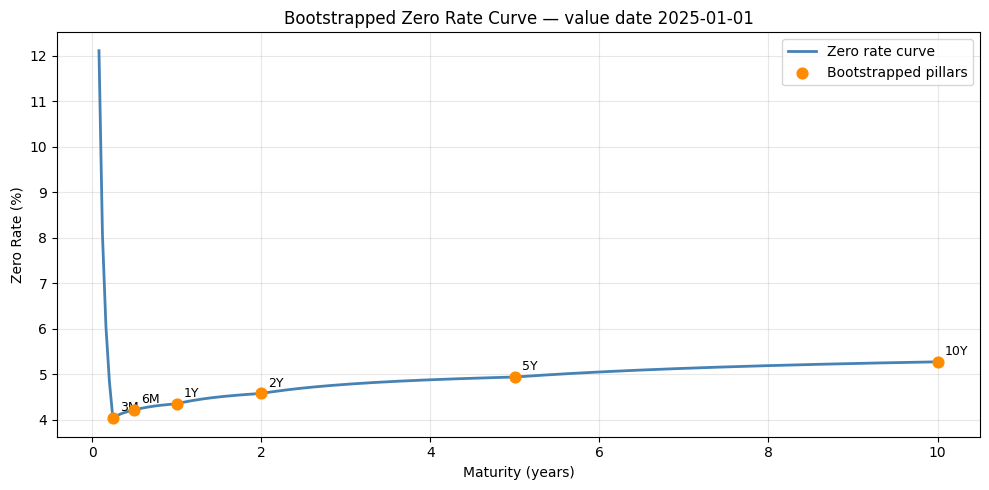

In [7]:
from datetime import datetime, timedelta

def maturity_years(date_str: str, value_date: str = VALUE_DATE) -> float:
    """Calendar days / 365 between value_date and date_str."""
    fmt = "%Y%m%d"
    return (datetime.strptime(date_str, fmt) - datetime.strptime(value_date, fmt)).days / 365.0

# Dense set of dates from 1M to 10Y for a smooth curve
start = datetime.strptime(VALUE_DATE, "%Y%m%d")
end   = datetime.strptime("20350101", "%Y%m%d")
date_range = []
d = start + timedelta(days=30)
while d <= end:
    date_range.append(d.strftime("%Y%m%d"))
    d += timedelta(days=15)

tenors   = [maturity_years(d) for d in date_range]
zero_rates_smooth = [curve.zero_rate(d) * 100 for d in date_range]

# Pillar points
pillar_tenors    = [maturity_years(d) for d in pillar_dates]
pillar_zero_rates = [curve.zero_rate(d) * 100 for d in pillar_dates]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tenors, zero_rates_smooth, color="steelblue", linewidth=2, label="Zero rate curve")
ax.scatter(pillar_tenors, pillar_zero_rates, color="darkorange", zorder=5, s=60, label="Bootstrapped pillars")
for label, x, y in zip(pillar_labels, pillar_tenors, pillar_zero_rates):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Zero Rate (%)")
ax.set_title("Bootstrapped Zero Rate Curve — value date 2025-01-01")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Plot: Discount Factor Curve

The discount factor curve is the present value of $1 at each future date. It is a strictly decreasing convex function starting at 1.0.

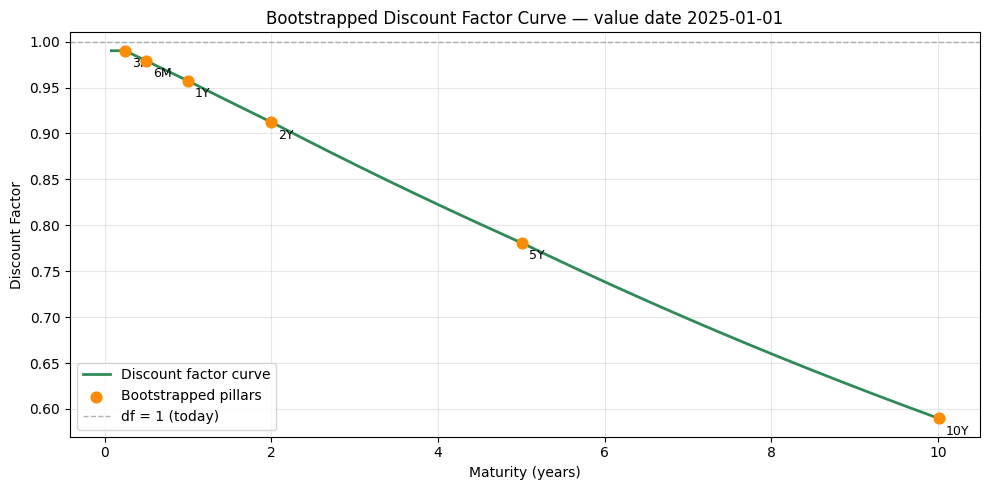

In [8]:
dfs_smooth = [curve.df(d) for d in date_range]
pillar_dfs = [curve.df(d) for d in pillar_dates]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tenors, dfs_smooth, color="seagreen", linewidth=2, label="Discount factor curve")
ax.scatter(pillar_tenors, pillar_dfs, color="darkorange", zorder=5, s=60, label="Bootstrapped pillars")
for label, x, y in zip(pillar_labels, pillar_tenors, pillar_dfs):
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(5, -12), fontsize=9)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, alpha=0.6, label="df = 1 (today)")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Discount Factor")
ax.set_title("Bootstrapped Discount Factor Curve — value date 2025-01-01")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Plot: Implied 1-Year Forward Rate Curve

The forward rate curve shows the market-implied rate for a 1-year lending period starting at each point in time. When the forward curve is above the zero curve, rates are expected to rise; when below, they are expected to fall.

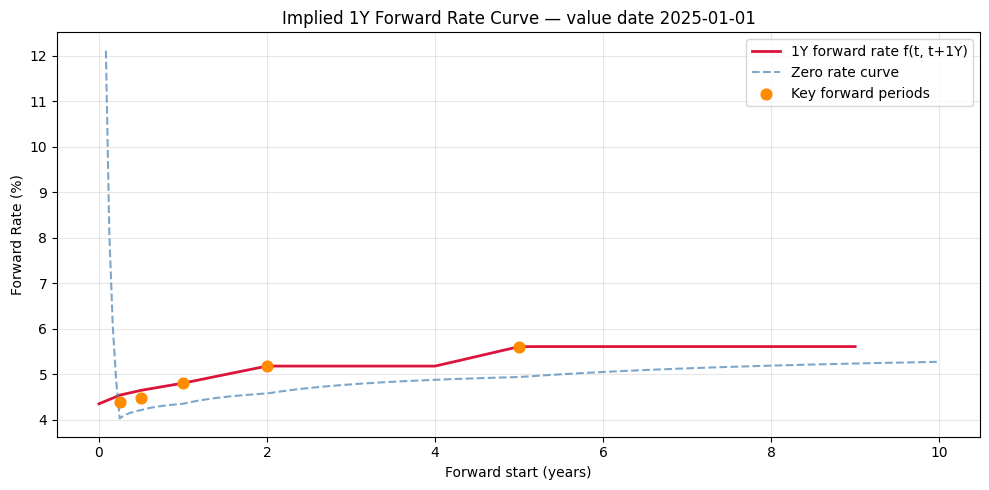

In [9]:
from datetime import datetime, timedelta

fmt = "%Y%m%d"

# Compute 1Y forward rates: f(t, t+1Y) for t from 0 to 9Y in steps of 0.25Y
fwd_start_tenors = np.arange(0.0, 9.25, 0.25)
fwd_rates = []
fwd_valid_tenors = []

value_dt = datetime.strptime(VALUE_DATE, fmt)
max_dt   = datetime.strptime("20350101", fmt)

for t in fwd_start_tenors:
    start_dt = value_dt + timedelta(days=round(t * 365))
    end_dt   = start_dt + timedelta(days=365)
    if end_dt > max_dt:
        break
    d1 = start_dt.strftime(fmt)
    d2 = end_dt.strftime(fmt)
    fwd_rates.append(curve.forward_rate(d1, d2) * 100)
    fwd_valid_tenors.append(t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fwd_valid_tenors, fwd_rates, color="crimson", linewidth=2, label="1Y forward rate f(t, t+1Y)")
ax.plot(tenors, zero_rates_smooth, color="steelblue", linewidth=1.5, linestyle="--", alpha=0.7, label="Zero rate curve")
ax.scatter(
    [t for label, d1, d2 in forward_pairs for t in [maturity_years(d1)]],
    [curve.forward_rate(d1, d2) * 100 for label, d1, d2 in forward_pairs],
    color="darkorange", zorder=5, s=60, label="Key forward periods"
)
ax.set_xlabel("Forward start (years)")
ax.set_ylabel("Forward Rate (%)")
ax.set_title("Implied 1Y Forward Rate Curve — value date 2025-01-01")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()